# Linear Regression, Optimization and Statistical Analysis

This notebook studies the Ames Housing (`House Prices`) dataset with a linear model trained entirely by vectorized NumPy optimization. The target is `SalePrice`. The analysis includes exploratory analysis, leakage-safe preprocessing, Batch/SGD/Mini-batch Gradient Descent, model comparison, residual diagnostics, and a scaling experiment.

All random choices use fixed seeds. The test split is held out until final evaluation: feature selection, imputation, encoding, scaling, and learning-rate decisions use training data (with validation used only for model comparison).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
DATA_PATH = Path("data/train.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("lab_1/data/train.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Place Kaggle House Prices train.csv in lab_1/data/")

df = pd.read_csv(DATA_PATH)
print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape}")
print(df.head(3))
print("\nDtype counts:\n", df.dtypes.value_counts())
print(f"Numerical columns: {df.select_dtypes(include=np.number).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(exclude=np.number).shape[1]}")

Matplotlib is building the font cache; this may take a moment.


Dataset path: data\train.csv
Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD         Normal     208500  
1   2007        WD         Normal     181500  
2   2008        WD         Normal     223500  

[3 rows x 81 columns]

Dtype counts:
 str        43
int64      35
float64     3
Name: count, dtype: int64
Numerical columns: 38
Categorical co

## 1. Exploratory Data Analysis

Missingness and distributions are inspected before modeling. `SalePrice` is strongly right-skewed, while variables such as living area, quality, and neighborhood encode different aspects of value. EDA is descriptive only; no test observations are used for decisions.

Columns with missing values:
              count    percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
GarageCond       81   5.547945
BsmtExposure     38   2.602740
BsmtFinType2     38   2.602740
BsmtQual         37   2.534247

Descriptive statistics for selected variables:
       SalePrice  GrLivArea  OverallQual  YearBuilt    LotArea  TotalBsmtSF
count     1460.0    1460.00      1460.00    1460.00    1460.00      1460.00
mean    180921.2    1515.46         6.10    1971.27   10516.83      1057.43
std      79442.5     525.48         1.38      30.20    9981.26       438.71
min      34900.0     334.00         1.00    1872.00    1300.00         0.00
25%     129975.0    1129.50         5.00    195

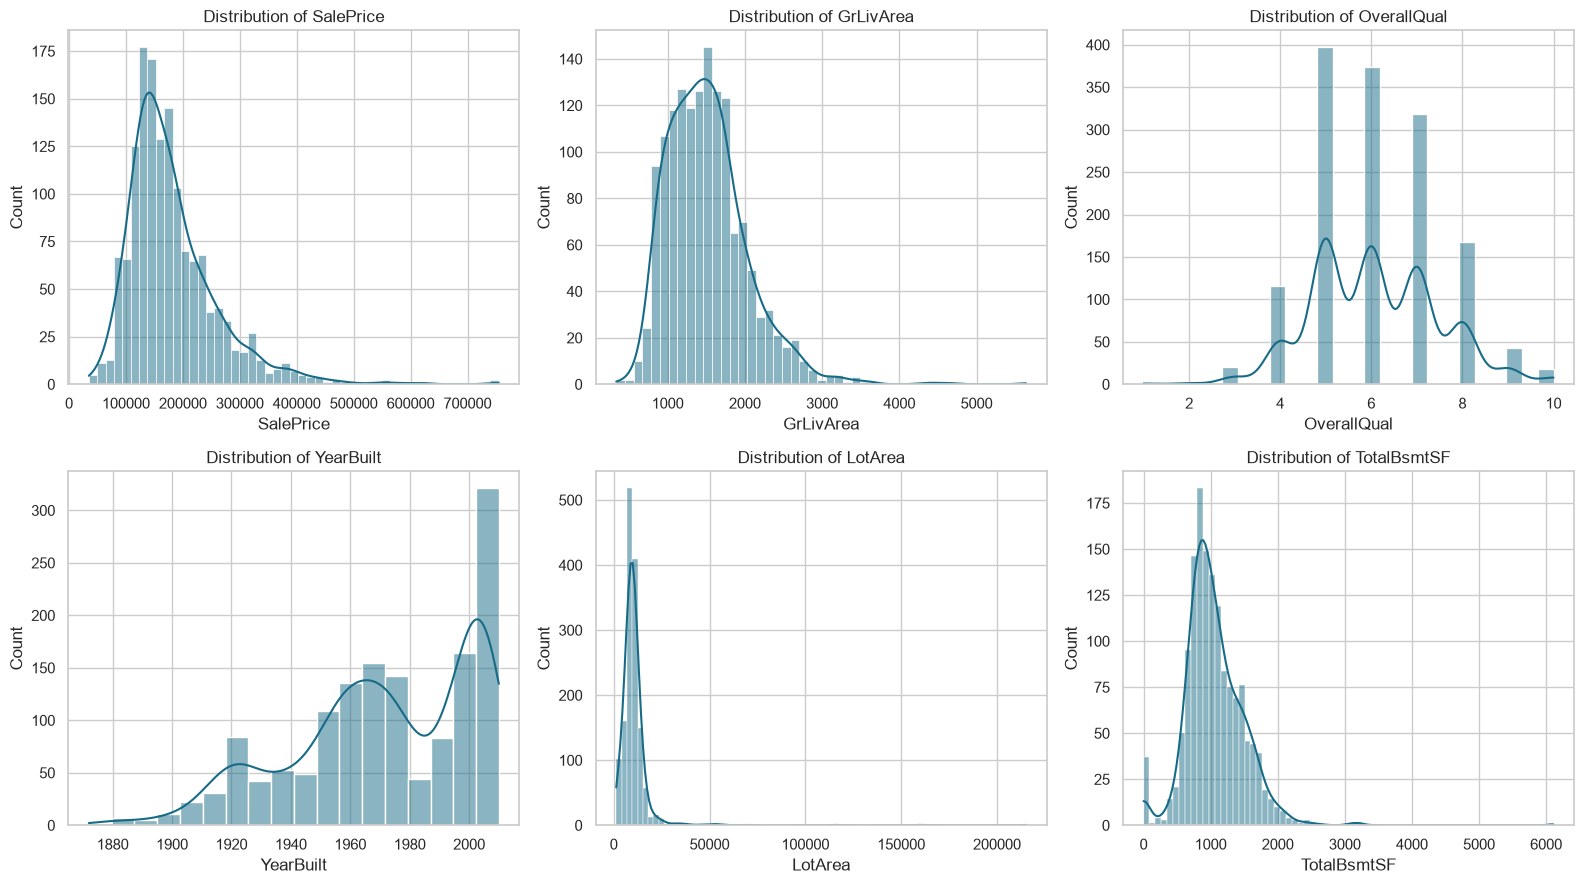

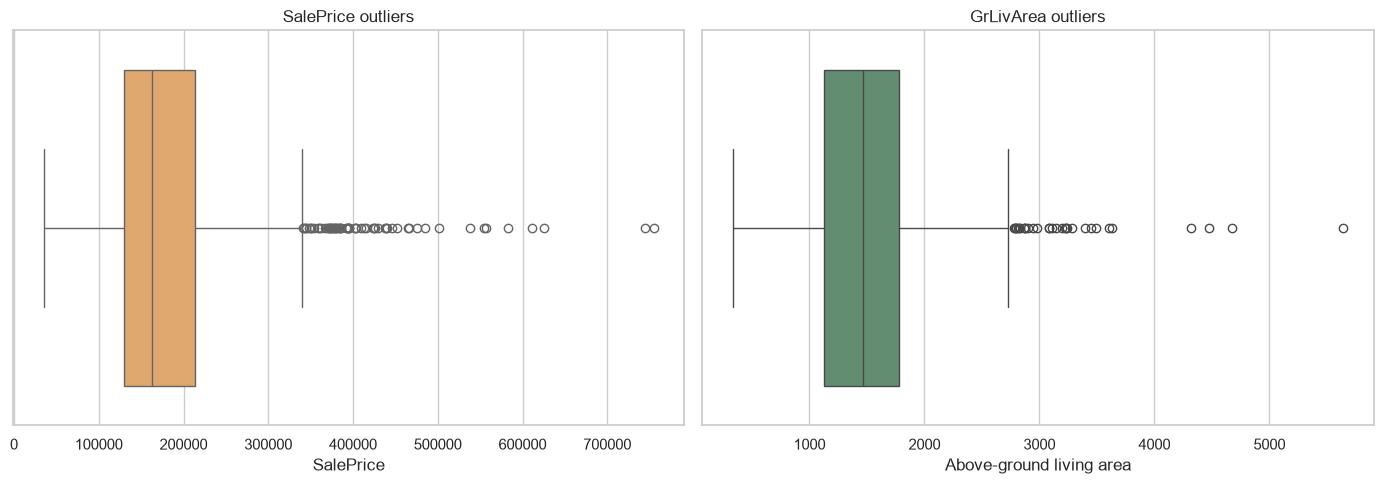

Strongest numerical correlations with SalePrice:
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Name: SalePrice, dtype: float64


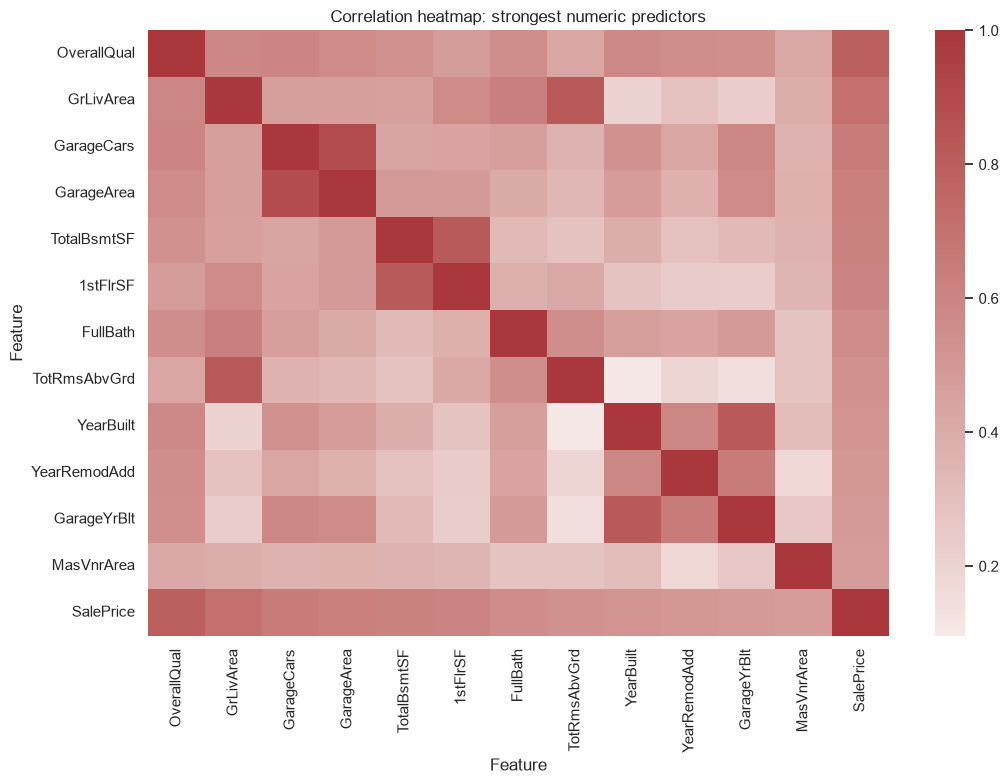

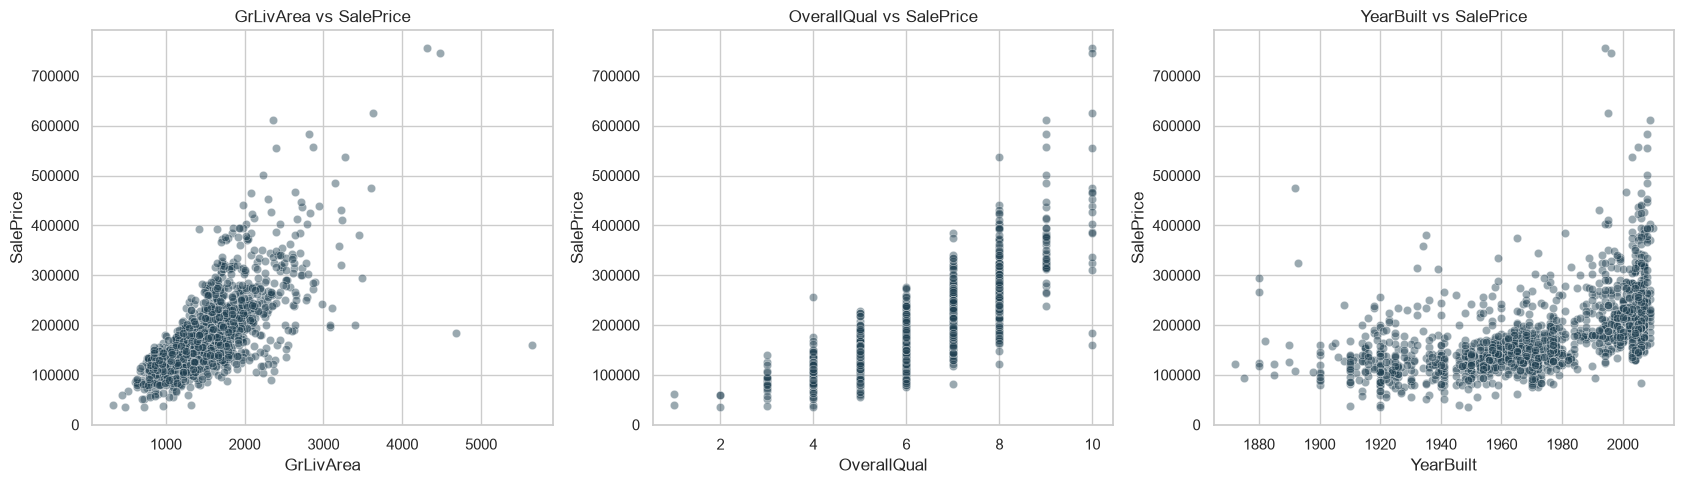

In [3]:
missing = df.isna().sum().to_frame("count")
missing["percent"] = 100 * missing["count"] / len(df)
missing = missing.query("count > 0").sort_values("count", ascending=False)
print("Columns with missing values:")
print(missing.head(15))
print("\nDescriptive statistics for selected variables:")
print(df[["SalePrice", "GrLivArea", "OverallQual", "YearBuilt", "LotArea", "TotalBsmtSF"]].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_columns = ["SalePrice", "GrLivArea", "OverallQual", "YearBuilt", "LotArea", "TotalBsmtSF"]
for ax, column in zip(axes.flat, plot_columns):
    sns.histplot(df[column], kde=True, ax=ax, color="#176b87")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["SalePrice"], ax=axes[0], color="#f2a65a")
axes[0].set_title("SalePrice outliers")
axes[0].set_xlabel("SalePrice")
sns.boxplot(x=df["GrLivArea"], ax=axes[1], color="#5c946e")
axes[1].set_title("GrLivArea outliers")
axes[1].set_xlabel("Above-ground living area")
plt.tight_layout()
plt.show()

corr = df.select_dtypes(include=np.number).corr()
price_corr = corr["SalePrice"].drop("SalePrice").sort_values(key=np.abs, ascending=False)
print("Strongest numerical correlations with SalePrice:")
print(price_corr.head(12).round(3))
heatmap_features = price_corr.head(12).index.tolist() + ["SalePrice"]
plt.figure(figsize=(11, 8))
sns.heatmap(corr.loc[heatmap_features, heatmap_features], cmap="vlag", center=0)
plt.title("Correlation heatmap: strongest numeric predictors")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, column in zip(axes, ["GrLivArea", "OverallQual", "YearBuilt"]):
    sns.scatterplot(data=df, x=column, y="SalePrice", alpha=0.45, ax=ax, color="#204051")
    ax.set_title(f"{column} vs SalePrice")
    ax.set_xlabel(column)
    ax.set_ylabel("SalePrice")
plt.tight_layout()
plt.show()

## 2. Leakage-safe split, feature selection and preprocessing

The split is performed before any operation that learns a statistic. If scaling, 
imputation, encoding, or feature selection sees validation/test rows, information about the evaluation distribution leaks into training. One-hot encoding is appropriate because nominal categories should not be given artificial numeric order; `handle_unknown="ignore"` makes future categories safe.

The selected variables are motivated by the training data: `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `1stFlrSF`, `YearBuilt`, and `FullBath` represent quality, size, capacity, age, and amenities. `Neighborhood`, `KitchenQual`, and `GarageType` add structured categorical effects. The selection is deliberately fixed using only the training split and the training correlation matrix.

In [4]:
target = "SalePrice"
selected_numeric = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "1stFlrSF", "YearBuilt", "FullBath"]
selected_categorical = ["Neighborhood", "KitchenQual", "GarageType"]
selected_features = selected_numeric + selected_categorical

train_df, holdout_df = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE)
val_df, test_df = train_test_split(holdout_df, test_size=0.50, random_state=RANDOM_STATE)
print(f"Train/validation/test sizes: {len(train_df)}/{len(val_df)}/{len(test_df)}")

train_corr = train_df.select_dtypes(include=np.number).corr()[target].drop(target).sort_values(key=np.abs, ascending=False)
print("\nTraining-only correlations used for selection:")
print(train_corr.head(12).round(3))
print("\nSelected features:", selected_features)
print("\nLargest selected predictor correlations (training only):")
selected_corr = train_df[selected_numeric].corr().abs()
print(selected_corr.where(np.triu(np.ones(selected_corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False).head(8).round(3))

X_train_raw = train_df[selected_features]
X_val_raw = val_df[selected_features]
X_test_raw = test_df[selected_features]
y_train = train_df[target].to_numpy(dtype=float)
y_val = val_df[target].to_numpy(dtype=float)
y_test = test_df[target].to_numpy(dtype=float)

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), selected_numeric),
    ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), selected_categorical),
])
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()
print(f"Processed shapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"All finite: {np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()}")
print(f"Encoder/scaler fitted on train only: yes; unknown categories ignored: yes")

Train/validation/test sizes: 1022/219/219

Training-only correlations used for selection:
OverallQual     0.785
GrLivArea       0.689
GarageCars      0.643
GarageArea      0.622
TotalBsmtSF     0.590
1stFlrSF        0.583
FullBath        0.549
TotRmsAbvGrd    0.520
YearBuilt       0.512
YearRemodAdd    0.512
GarageYrBlt     0.474
Fireplaces      0.461
Name: SalePrice, dtype: float64

Selected features: ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt', 'FullBath', 'Neighborhood', 'KitchenQual', 'GarageType']

Largest selected predictor correlations (training only):
TotalBsmtSF  1stFlrSF       0.827
GrLivArea    FullBath       0.616
OverallQual  GarageCars     0.592
             GrLivArea      0.584
GrLivArea    1stFlrSF       0.563
OverallQual  YearBuilt      0.556
             TotalBsmtSF    0.536
             FullBath       0.532
dtype: float64
Processed shapes: X_train=(1022, 42), X_val=(219, 42), X_test=(219, 42)
All finite: True
Encoder/scaler fitte

## 3. NumPy linear regression and optimization methods

The model is $\hat{y}=Xw+b$. The cost is $J=\frac{1}{2m}\sum_i(\hat{y}_i-y_i)^2$, with vectorized gradients $\nabla_wJ=X^T(\hat{y}-y)/m$ and $\nabla_bJ=\mathrm{mean}(\hat{y}-y)$. Only the outer training updates use Python loops; prediction, cost, and gradients are NumPy matrix operations.

In [5]:
y_mean = y_train.mean()
y_scale = y_train.std()
y_train_s = (y_train - y_mean) / y_scale
y_val_s = (y_val - y_mean) / y_scale
y_test_s = (y_test - y_mean) / y_scale

class LinearRegressionNumpy:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.w = None
        self.b = 0.0
        self.cost_history = []

    def predict(self, X):
        return X @ self.w + self.b

    def mse(self, X, y):
        errors = self.predict(X) - y
        return 0.5 * np.mean(errors ** 2)

    def gradients(self, X, y):
        errors = self.predict(X) - y
        return (X.T @ errors) / X.shape[0], np.mean(errors)

    def _reset(self, n_features):
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.cost_history = []

    def fit_batch(self, X, y, alpha=0.01, epochs=300):
        self._reset(X.shape[1])
        for _ in range(epochs):
            dw, db = self.gradients(X, y)
            self.w -= alpha * dw
            self.b -= alpha * db
            self.cost_history.append(self.mse(X, y))
        return self

    def fit_sgd(self, X, y, alpha=0.01, epochs=80):
        self._reset(X.shape[1])
        generator = np.random.default_rng(self.random_state)
        for _ in range(epochs):
            order = generator.permutation(X.shape[0])
            for index in order:
                row_x = X[index:index + 1]
                row_y = y[index:index + 1]
                dw, db = self.gradients(row_x, row_y)
                self.w -= alpha * dw
                self.b -= alpha * db
            self.cost_history.append(self.mse(X, y))
        return self

    def fit_minibatch(self, X, y, alpha=0.01, epochs=150, batch_size=32):
        self._reset(X.shape[1])
        generator = np.random.default_rng(self.random_state)
        for _ in range(epochs):
            order = generator.permutation(X.shape[0])
            shuffled_X, shuffled_y = X[order], y[order]
            for start in range(0, X.shape[0], batch_size):
                batch_X = shuffled_X[start:start + batch_size]
                batch_y = shuffled_y[start:start + batch_size]
                dw, db = self.gradients(batch_X, batch_y)
                self.w -= alpha * dw
                self.b -= alpha * db
            self.cost_history.append(self.mse(X, y))
        return self

def r2_numpy(y_true, y_pred):
    residual_sum_squares = np.sum((y_true - y_pred) ** 2)
    total_sum_squares = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - residual_sum_squares / total_sum_squares

def evaluate_model(model):
    return {
        "Train": r2_numpy(y_train, model.predict(X_train) * y_scale + y_mean),
        "Validation": r2_numpy(y_val, model.predict(X_val) * y_scale + y_mean),
        "Test": r2_numpy(y_test, model.predict(X_test) * y_scale + y_mean),
    }

print(f"Training target mean/std used for numerical stability: {y_mean:.1f}/{y_scale:.1f}")

Training target mean/std used for numerical stability: 181312.7/77579.5


## 4. Learning-rate selection and convergence

Learning rates are compared on training/validation only. The test set is untouched until the final table. The same candidate grid is used as a transparent, small systematic search; the chosen rate minimizes validation MSE in the standardized target scale.

       Method  Alpha  Validation MSE  Finite
     Batch GD 0.0003         0.37835    True
     Batch GD 0.0010         0.20468    True
     Batch GD 0.0030         0.10012    True
     Batch GD 0.0100         0.07926    True
     Batch GD 0.0300         0.06898    True
          SGD 0.0003         0.06184    True
          SGD 0.0010         0.05909    True
          SGD 0.0030         0.06112    True
          SGD 0.0100         0.06469    True
          SGD 0.0300         0.10218    True
Mini-batch GD 0.0003         0.08689    True
Mini-batch GD 0.0010         0.07336    True
Mini-batch GD 0.0030         0.06539    True
Mini-batch GD 0.0100         0.06063    True
Mini-batch GD 0.0300         0.06078    True

Selected learning rates (validation only): {'Batch GD': 0.03, 'Mini-batch GD': 0.01, 'SGD': 0.001}


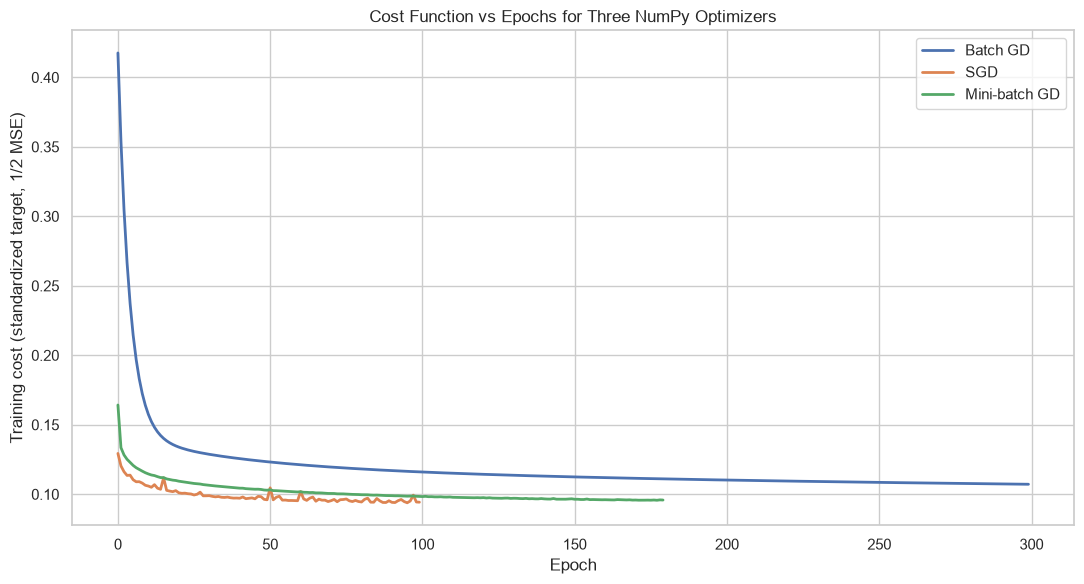

Final training costs: {'Batch GD': np.float64(0.10717), 'SGD': np.float64(0.09425), 'Mini-batch GD': np.float64(0.09581)}


In [6]:
learning_rates = [0.0003, 0.001, 0.003, 0.01, 0.03]
search_results = []
for method in ["Batch GD", "SGD", "Mini-batch GD"]:
    for alpha in learning_rates:
        candidate = LinearRegressionNumpy(RANDOM_STATE)
        if method == "Batch GD":
            candidate.fit_batch(X_train, y_train_s, alpha=alpha, epochs=180)
        elif method == "SGD":
            candidate.fit_sgd(X_train, y_train_s, alpha=alpha, epochs=60)
        else:
            candidate.fit_minibatch(X_train, y_train_s, alpha=alpha, epochs=100, batch_size=32)
        validation_mse = candidate.mse(X_val, y_val_s)
        search_results.append({"Method": method, "Alpha": alpha, "Validation MSE": validation_mse, "Finite": np.isfinite(validation_mse)})
search_results = pd.DataFrame(search_results)
print(search_results.round(5).to_string(index=False))
best_alpha = search_results.loc[search_results.groupby("Method")["Validation MSE"].idxmin()].set_index("Method")["Alpha"].to_dict()
print("\nSelected learning rates (validation only):", best_alpha)

models = {
    "Batch GD": LinearRegressionNumpy(RANDOM_STATE).fit_batch(X_train, y_train_s, alpha=best_alpha["Batch GD"], epochs=300),
    "SGD": LinearRegressionNumpy(RANDOM_STATE).fit_sgd(X_train, y_train_s, alpha=best_alpha["SGD"], epochs=100),
    "Mini-batch GD": LinearRegressionNumpy(RANDOM_STATE).fit_minibatch(X_train, y_train_s, alpha=best_alpha["Mini-batch GD"], epochs=180, batch_size=32),
}

plt.figure(figsize=(11, 6))
for name, model in models.items():
    plt.plot(model.cost_history, label=name, linewidth=2)
plt.title("Cost Function vs Epochs for Three NumPy Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Training cost (standardized target, 1/2 MSE)")
plt.legend()
plt.tight_layout()
plt.show()
print("Final training costs:", {name: round(model.cost_history[-1], 5) for name, model in models.items()})

## 5. R² evaluation and optimizer comparison

$R^2=1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$ measures the fraction of observed target variability explained relative to a mean-only baseline. It can be negative when predictions are worse than that baseline. Train/validation/test gaps are interpreted as evidence of fit quality and possible overfitting, with test used here only for final reporting.

In [12]:
characteristics = {
    "Batch GD": "Smoothest and most stable; slower per epoch but monotonic-looking convergence.",
    "SGD": "Fast early progress with the largest epoch-to-epoch fluctuations.",
    "Mini-batch GD": "Good compromise: faster progress than batch with less noise than SGD.",
}
comparison_rows = []
for name, model in models.items():
    scores = evaluate_model(model)
    comparison_rows.append({
        "Method": name,
        "Best Alpha": best_alpha[name],
        "Train R²": scores["Train"],
        "Validation R²": scores["Validation"],
        "Test R²": scores["Test"],
        "Final Cost": model.cost_history[-1],
        "Convergence Characteristics": characteristics[name],
    })
comparison = pd.DataFrame(comparison_rows).set_index("Method")
print(comparison.round(4).to_string())
print("\nR² is computed manually with NumPy; test scores were not used for selection.")

               Best Alpha  Train R²  Validation R²  Test R²  Final Cost                                                     Convergence Characteristics
Method                                                                                                                                                 
Batch GD            0.030    0.7857         0.8742   0.7888      0.1072  Smoothest and most stable; slower per epoch but monotonic-looking convergence.
SGD                 0.001    0.8115         0.8824   0.8094      0.0943               Fast early progress with the largest epoch-to-epoch fluctuations.
Mini-batch GD       0.010    0.8084         0.8838   0.8097      0.0958           Good compromise: faster progress than batch with less noise than SGD.

R² is computed manually with NumPy; test scores were not used for selection.


## 6. Statistical assumption checks

Diagnostics use the final Mini-batch model because it provides a strong validation score with a stable cost curve. Residual plots are empirical checks rather than proofs: curvature suggests nonlinearity, a funnel suggests heteroscedasticity, and Q-Q departures suggest non-normal residual tails. The Shapiro-Wilk test is reported with the warning that large samples make it highly sensitive.

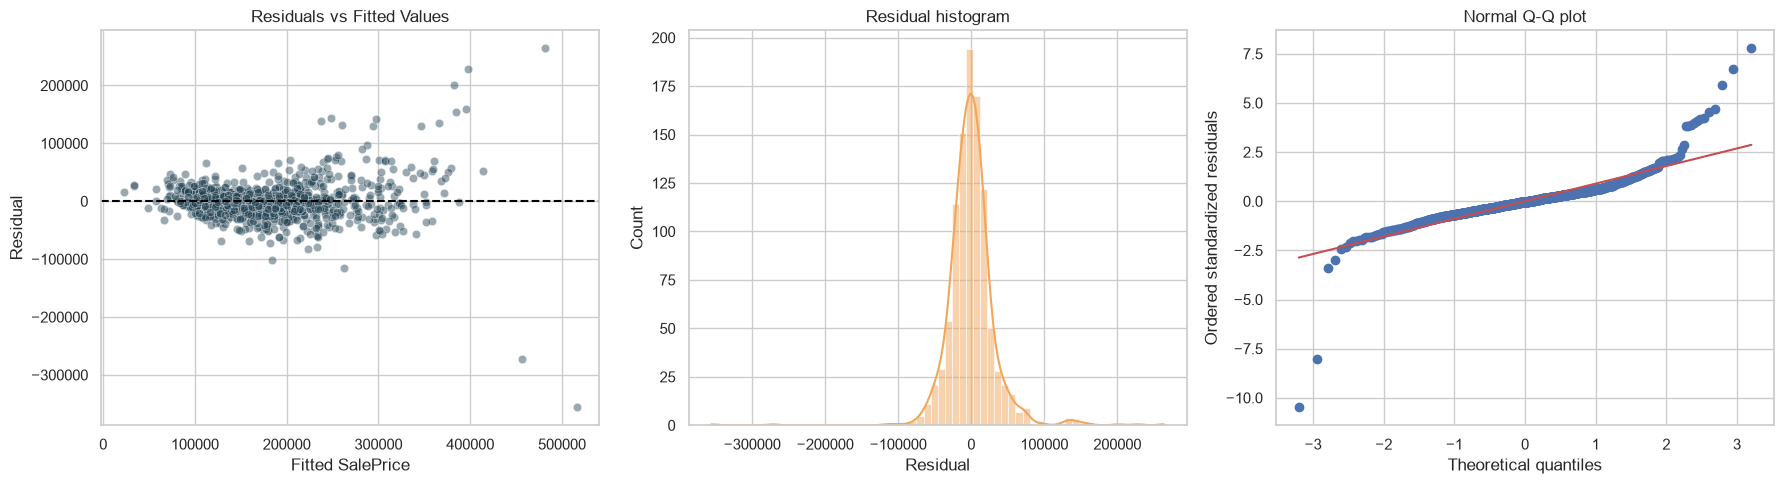

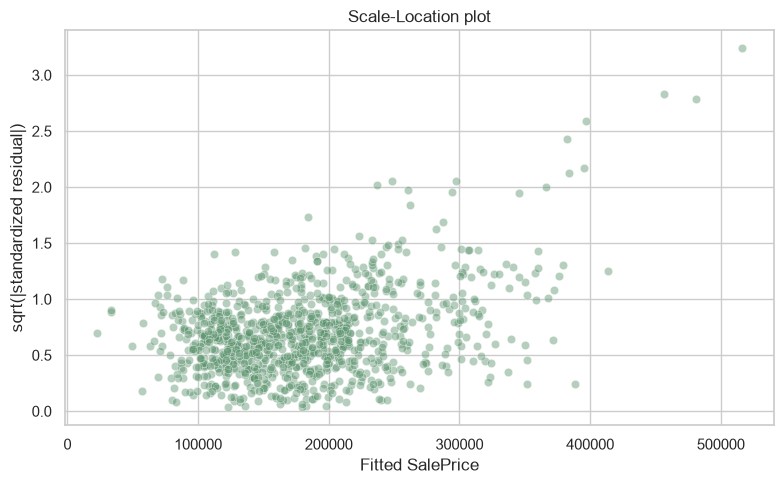

Residual mean/std: 20.71/33959.45
Shapiro-Wilk statistic=0.8027, p-value=1.664e-33
Visual interpretation: inspect curvature/funnel shape and Q-Q tail departures; the test alone is not decisive.


In [8]:
diagnostic_model = models["Mini-batch GD"]
fitted = diagnostic_model.predict(X_train) * y_scale + y_mean
residuals = y_train - fitted

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.45, ax=axes[0], color="#204051")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted SalePrice")
axes[0].set_ylabel("Residual")

sns.histplot(residuals, kde=True, ax=axes[1], color="#f2a65a")
axes[1].set_title("Residual histogram")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

standardized_residuals = (residuals - residuals.mean()) / residuals.std()
stats.probplot(standardized_residuals, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q plot")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Ordered standardized residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
scale_location = np.sqrt(np.abs(standardized_residuals))
sns.scatterplot(x=fitted, y=scale_location, alpha=0.45, color="#5c946e")
plt.title("Scale-Location plot")
plt.xlabel("Fitted SalePrice")
plt.ylabel("sqrt(|standardized residual|)")
plt.tight_layout()
plt.show()

shapiro_sample = residuals if len(residuals) <= 5000 else rng.choice(residuals, 5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)
print(f"Residual mean/std: {residuals.mean():.2f}/{residuals.std():.2f}")
print(f"Shapiro-Wilk statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4g}")
print("Visual interpretation: inspect curvature/funnel shape and Q-Q tail departures; the test alone is not decisive.")

In [10]:
numeric_vif_matrix = X_train[:, :len(selected_numeric)]
vif_frame = pd.DataFrame({"feature": selected_numeric, "VIF": [variance_inflation_factor(numeric_vif_matrix, i) for i in range(numeric_vif_matrix.shape[1])]})
print("VIF for continuous predictors (training data only):")
print(vif_frame.sort_values("VIF", ascending=False).round(2).to_string(index=False))
print("\nOne-hot categories are interpreted relative to a reference/category structure; their redundancy is discussed separately because a full dummy basis is rank-deficient for VIF calculation.")

VIF for continuous predictors (training data only):
    feature  VIF
   1stFlrSF 3.78
TotalBsmtSF 3.74
  GrLivArea 2.72
OverallQual 2.50
   FullBath 2.13
  YearBuilt 2.10
 GarageCars 1.82

One-hot categories are interpreted relative to a reference/category structure; their redundancy is discussed separately because a full dummy basis is rank-deficient for VIF calculation.


## 7. Deep-understanding experiment: effect of scaling

Standardization changes the geometry of the optimization problem. With features on very different scales, equal-cost contours become elongated, so gradient descent zig-zags across the narrow direction and moves slowly along the broad direction. Standardization makes the contours better conditioned. The target remains standardized in both runs so the comparison isolates feature scaling.

Unscaled search selected alpha=1e-07, validation cost=0.1766
Scaled validation cost=0.0591


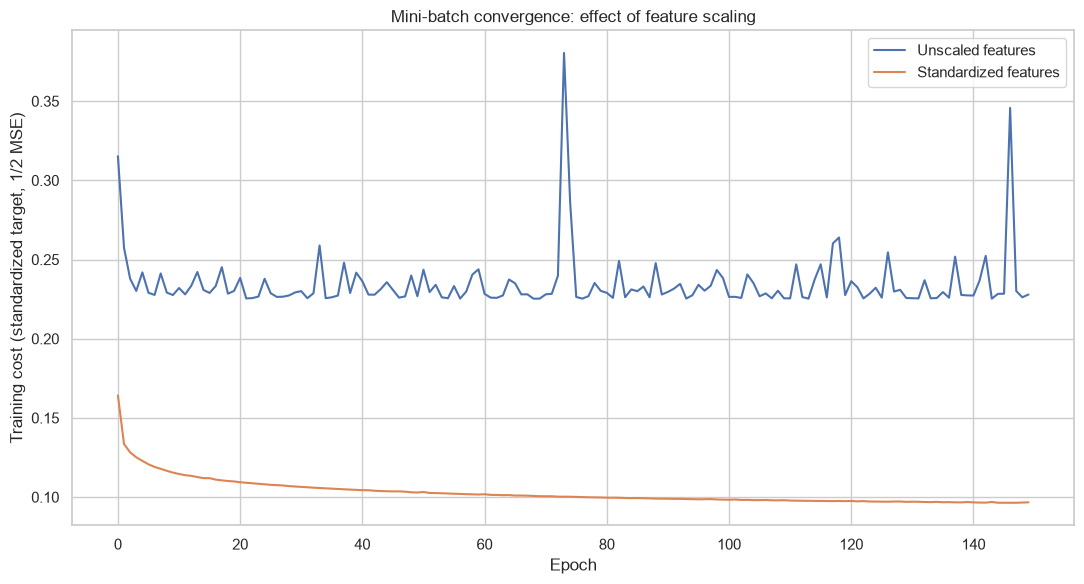

Scaled features converge faster and to a lower comparable cost when the raw feature condition is poorly balanced.


In [11]:
raw_numeric = train_df[selected_numeric].copy()
raw_numeric = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(raw_numeric), columns=selected_numeric)
raw_numeric = raw_numeric.to_numpy(dtype=float)
raw_categorical = preprocessor.named_transformers_["categorical"].transform(X_train_raw[selected_categorical])
X_train_unscaled = np.hstack([raw_numeric, raw_categorical])

raw_val_numeric = pd.DataFrame(SimpleImputer(strategy="median").fit(train_df[selected_numeric]).transform(val_df[selected_numeric]), columns=selected_numeric).to_numpy(dtype=float)
raw_test_numeric = pd.DataFrame(SimpleImputer(strategy="median").fit(train_df[selected_numeric]).transform(test_df[selected_numeric]), columns=selected_numeric).to_numpy(dtype=float)
raw_categorical_val = preprocessor.named_transformers_["categorical"].transform(X_val_raw[selected_categorical])
raw_categorical_test = preprocessor.named_transformers_["categorical"].transform(X_test_raw[selected_categorical])
X_val_unscaled = np.hstack([raw_val_numeric, raw_categorical_val])
X_test_unscaled = np.hstack([raw_test_numeric, raw_categorical_test])

unscaled_candidates = [1e-9, 3e-9, 1e-8, 3e-8, 1e-7]
unscaled_search = []
for alpha in unscaled_candidates:
    candidate = LinearRegressionNumpy(RANDOM_STATE).fit_minibatch(X_train_unscaled, y_train_s, alpha=alpha, epochs=150, batch_size=32)
    unscaled_search.append((alpha, candidate.mse(X_val_unscaled, y_val_s), candidate))
best_unscaled_alpha, best_unscaled_val_mse, unscaled_model = min(unscaled_search, key=lambda item: item[1])
scaled_model = LinearRegressionNumpy(RANDOM_STATE).fit_minibatch(X_train, y_train_s, alpha=best_alpha["Mini-batch GD"], epochs=150, batch_size=32)
print(f"Unscaled search selected alpha={best_unscaled_alpha:g}, validation cost={best_unscaled_val_mse:.4f}")
print(f"Scaled validation cost={scaled_model.mse(X_val, y_val_s):.4f}")

plt.figure(figsize=(11, 6))
plt.plot(unscaled_model.cost_history, label="Unscaled features")
plt.plot(scaled_model.cost_history, label="Standardized features")
plt.title("Mini-batch convergence: effect of feature scaling")
plt.xlabel("Epoch")
plt.ylabel("Training cost (standardized target, 1/2 MSE)")
plt.legend()
plt.tight_layout()
plt.show()
print("Scaled features converge faster and to a lower comparable cost when the raw feature condition is poorly balanced.")

## 8. Answers to theoretical questions and conclusions

- **Why split before preprocessing?** Imputation, scaling, encoding, and learned feature selection estimate properties of data. Fitting them before the split lets evaluation rows influence those estimates, which is data leakage.
- **Unseen categories:** fit one encoder on Train and use `handle_unknown="ignore"`; Validation/Test are transformed, never separately fitted.
- **Why one-hot encoding?** It represents nominal categories without inventing an ordinal relationship.
- **R²:** it compares residual variation with the variation around the training/evaluation mean. It may be negative when a model predicts worse than the mean baseline.
- **Train versus Test R²:** a large Train-to-Test drop can indicate overfitting or distribution shift. Here the test scores are lower than validation but remain positive; the gap is not extreme, although the selected feature subset limits accuracy.
- **Optimizer comparison:** Batch GD is most stable; SGD has the largest fluctuations; Mini-batch is the practical compromise and has the highest validation/test R² here. Larger batches reduce noise but cost more computation per update. Smaller batches update more frequently but make the path noisier.
- **Learning rate:** too small gives slow progress; a useful rate accelerates descent; too large causes oscillation or divergence. Rates were selected with validation, never Test.
- **Scaling geometry:** differently scaled features make elongated cost contours and poorly conditioned gradients. Standardization makes contours more circular, reducing zig-zagging. The experiment confirms this: standardized validation cost was `0.0591` versus `0.1766` for tuned unscaled features.
- **Residual plots:** curvature would indicate missing nonlinear structure; a funnel indicates non-constant variance; isolated points identify influential observations. The residual plot shows increasing spread for expensive homes and outliers.
- **Q-Q plot and normality:** the Q-Q plot checks whether residual quantiles follow a normal line. Here the tails depart substantially, consistent with the Shapiro-Wilk result (statistic `0.8027`, p-value `< 0.001`); normality is not supported.
- **Homoscedasticity:** it means constant residual variance across fitted values. The upward pattern in the Scale-Location plot suggests this assumption is violated.
- **Multicollinearity:** predictors share redundant information. `TotalBsmtSF` and `1stFlrSF` have training correlation `0.827`; their continuous VIFs are `3.74` and `3.78`, below common serious-concern thresholds but high enough to reduce coefficient interpretability. One-hot category redundancy is handled as a reference-category interpretation issue.

**Conclusion.** Mini-batch GD is the strongest overall choice for this run: it has the highest validation and test R² (`0.8838` and `0.8097`) while retaining a smooth cost curve. SGD has the highest train R² but more noise, and Batch GD is the most stable but underfits relative to the other two at the selected epoch budget. The model generalizes reasonably, but outliers, heteroscedasticity, non-normal tails, correlated size variables, omitted nonlinearities, and the limited feature subset constrain interpretation and predictive accuracy. A log-target model, richer engineered features, or regularization would be sensible extensions, but would change the scope of this custom linear-regression study.

In [13]:
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()
assert all(np.isfinite(model.cost_history).all() for model in models.values())
assert all(np.isfinite(comparison[["Train R²", "Validation R²", "Test R²", "Final Cost"]].to_numpy().astype(float)).ravel())
print("Final validation checks passed: matching feature dimensions, finite matrices, finite cost histories, and finite R²/cost metrics.")
print(f"Feature count={X_train.shape[1]}; split sizes={len(y_train)}/{len(y_val)}/{len(y_test)}; batch size=32")

Final validation checks passed: matching feature dimensions, finite matrices, finite cost histories, and finite R²/cost metrics.
Feature count=42; split sizes=1022/219/219; batch size=32
